# Executive Exploratory Data Analysis

# 1. Executive Summary

Our analysis establishes a data-driven framework for improving Bitcoin (BTC) accumulation by synthesizing on-chain signals with real-time speculative conviction from Polymarket prediction markets. The core thesis is that standard Dollar-Cost Averaging (DCA) leaves significant performance on the table while a dynamic, signal-weighted approach using polymarket data can systematically identify better accumulation windows.

Our EDA identifies four complementary signals that, when combined, define a **"Golden Entry" regime** — a convergence of structural undervaluation, active network participation, low macro risk, and smart-money conviction:

- **Signal 1 — On-Chain Active Churn:** The most favorable accumulation windows occur not during panic-driven extreme outflows but during a moderate "active churn" state where net exchange outflows are positive (coins leaving exchanges) and active address count remains elevated. This combination — undervaluation plus engaged participation — consistently precedes superior 30-day forward returns.

- **Signal 2 — Macro Event Anchor:** Polymarket event intensity functions as a structural risk filter rather than a return predictor. Moderate-to-high event activity days are associated with significantly lower forward drawdown probability. Conversely, "informational vacuum" periods with no active events carry elevated downside risk. Additionally, BTC price variance compresses as major events approach resolution — a predictable volatility squeeze that should dampen position-sizing aggression near resolution dates.

- **Signal 3 — Whale Smart Money:** Large trades (>$10k notional) on crypto-relevant Polymarket markets reveal directional conviction from sophisticated participants. When size-weighted net flow from whale activity on bullish outcomes is positive, it provides a lead indicator for BTC sentiment ahead of price moves.

- **Signal 4 — Risk Index Regime Filter:** The Polymarket Risk Index — the cross-market average of 7-day probability volatility — acts as a macro regime indicator. Higher risk index levels coincide with elevated BTC price regimes (bull markets), while low risk index periods correlate with undervalued accumulation phases. This creates a multiplicative filter on the core MVRV signal: amplify accumulation when the regime appears early-cycle, dampen it when the regime appears late-cycle.

These four signals are integrated into a dynamic DCA model that achieved a **68.05% win rate** across 2,557 rolling 1-year backtested windows (vs. uniform DCA), with a **Final Model Score of 63.4%** and a **21.1% mean relative improvement** in sats accumulated per dollar invested.

# 2. Data Retrieval

In this EDA, we use two main data sources:

- Coin Metrics BTC daily dataset (coinmetrics_btc.csv) for price and on-chain features.

- Polymarket finance & politics Parquet exports (markets, tokens, trades, odds history, event statistics,) to capture prediction market activity and pricing behavior.

### 2.1 CoinMetrics

We restrict the sample period to 2018-01-01 through 2025-12-31 to maintain consistency across datasets. The data is sorted chronologically and verified to have a strictly increasing, unique time index.

Based on PriceUSD, we construct daily returns, log returns, 200-day moving average, relative deviation from the moving average, and drawdown. We also generate forward-looking metrics such as 30-day annualized volatility, forward returns, and forward maximum drawdown. In addition, we apply quintile binning to MVRV and Net Flow to normalize on-chain valuation and capital flow signals for cross-feature comparison.

### 2.2 Polymarket

Six Parquet files exported, all scoped to finance and politics markets (crypto, business, politics categories):

- **Markets** — structural metadata (question, category, volume, creation date, end date) for all relevant prediction markets
- **Tokens** — maps each market to its outcome tokens (e.g. Yes/No, Trump/Harris)
- **Trades** — granular trade-level logs with timestamp, price, size, side, and wallet addresses
- **Odds History** — time-series of probabilities, used to construct the risk index
- **Event Stats** — aggregated event-level statistics (total volume, market count, start/end dates)

Daily Polymarket features constructed: active event count and total volume (risk regime indicator), the Odds History risk index (cross-market mean of 7-day probability volatility), and the whale directional flow signal from the trades data.

# 3. General Dataset Overview

## 3.1 Coinmetrics

The Coin Metrics dataset contains 2,922 daily observations from 2018-01-01 to 2025-12-31. The time index is strictly increasing with no duplicate timestamps, indicating a clean and well-structured time series.

Most core price and on-chain variables have no missing values. Several ReferenceRate columns are entirely empty and are excluded from analysis, while CapMrktEstUSD has partial missing values (~18%) and would require careful handling if used in modeling. Overall, the dataset shows strong completeness for key variables such as price, transaction counts, supply, and valuation metrics.

From 2018 to 2025, BTC experienced multiple market cycles, including a post-2018 decline, a strong 2020–2021 bull market, a sharp 2022 correction, and renewed volatility after 2023. Market capitalization closely mirrors price, as expected. Hashrate, however, shows a more structural upward trend, reflecting long-term network growth despite cyclical price fluctuations.

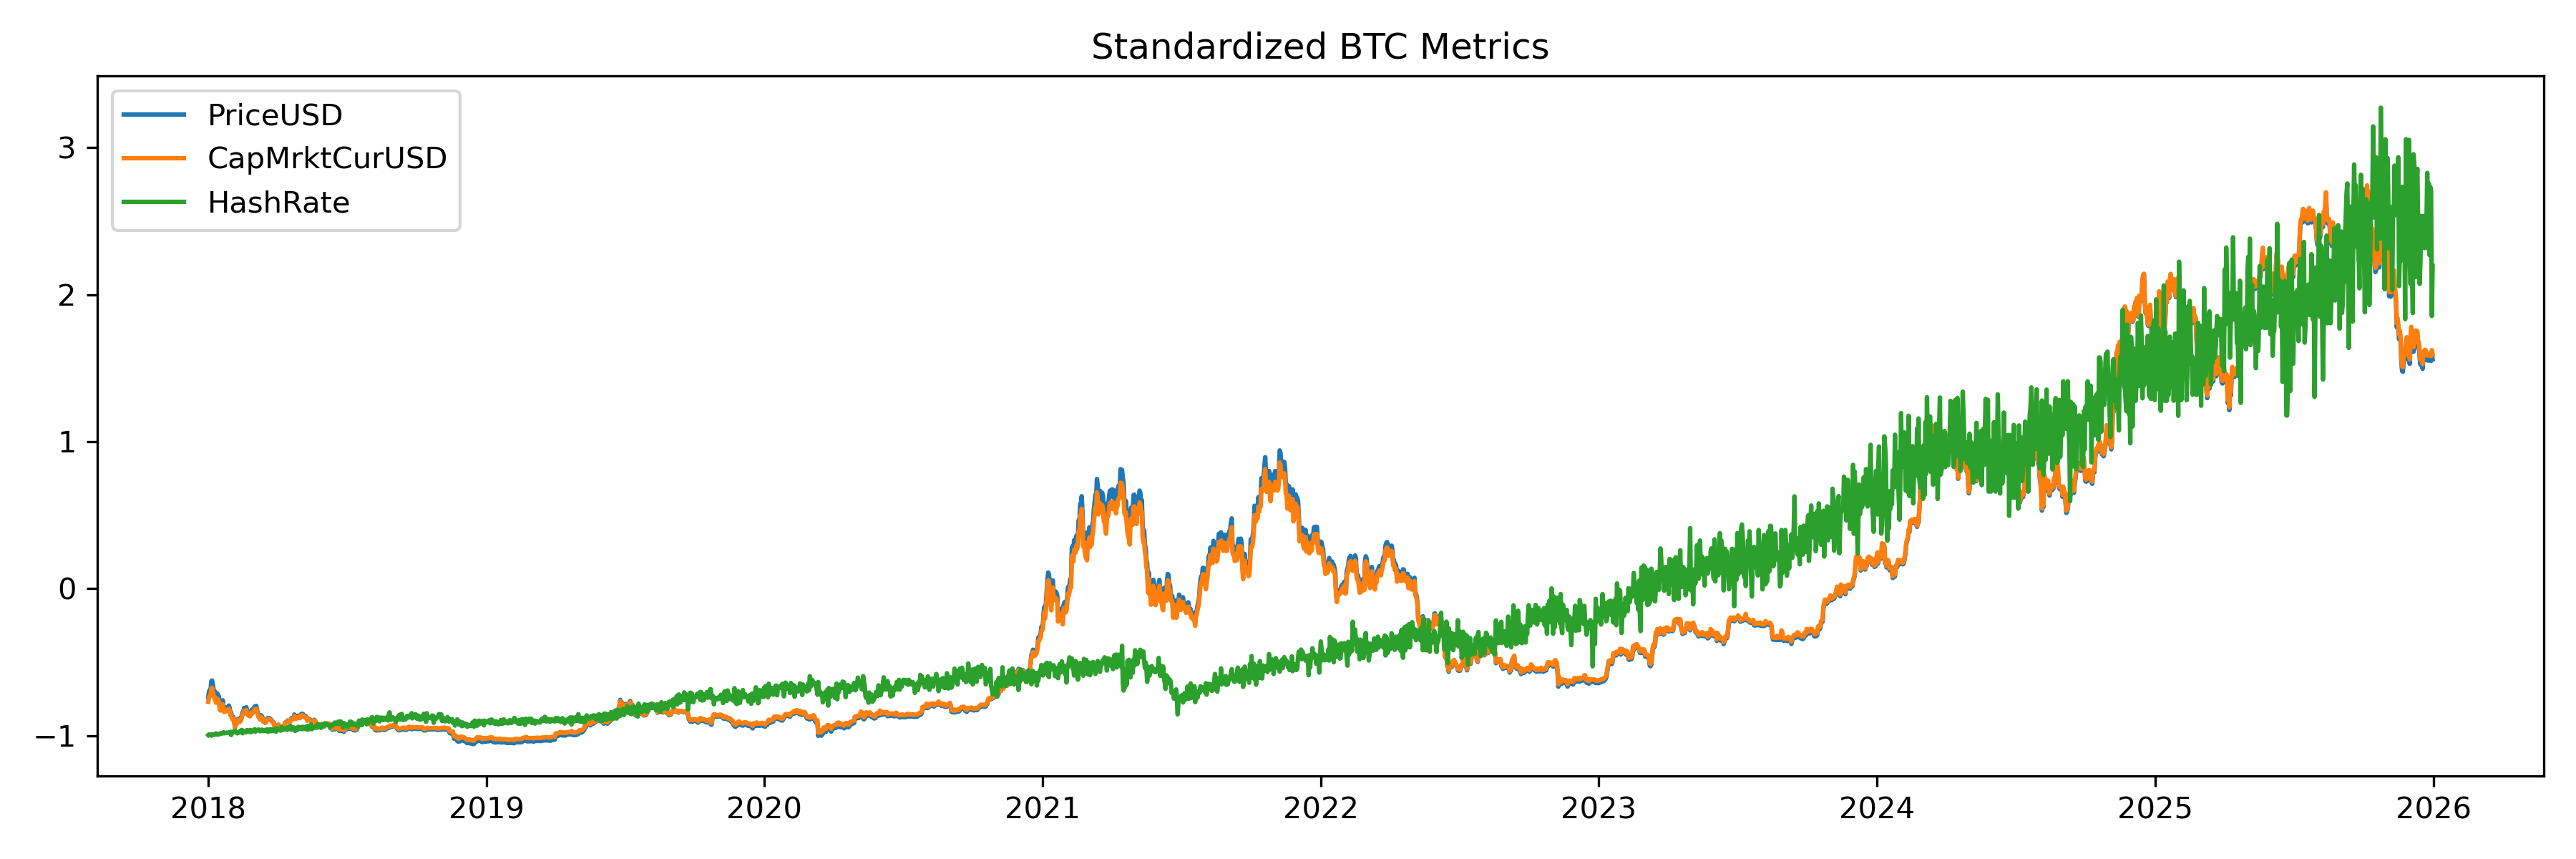

In [19]:
from IPython.display import Image, display
display(Image("plots/Standardized BTC Metrics.png"),width=800)

The correlation matrix reveals several important structural relationships. Price and market cap are nearly perfectly correlated (mechanical). Exchange inflows and outflows move together, meaning the difference of the two (netflow) contains more signal than either series alone. Active address count shows weak correlation with price — confirming it carries genuinely independent information about network participation, which motivated its inclusion in Signal 1. MVRV shows moderate correlation with price, consistent with its valuation role.

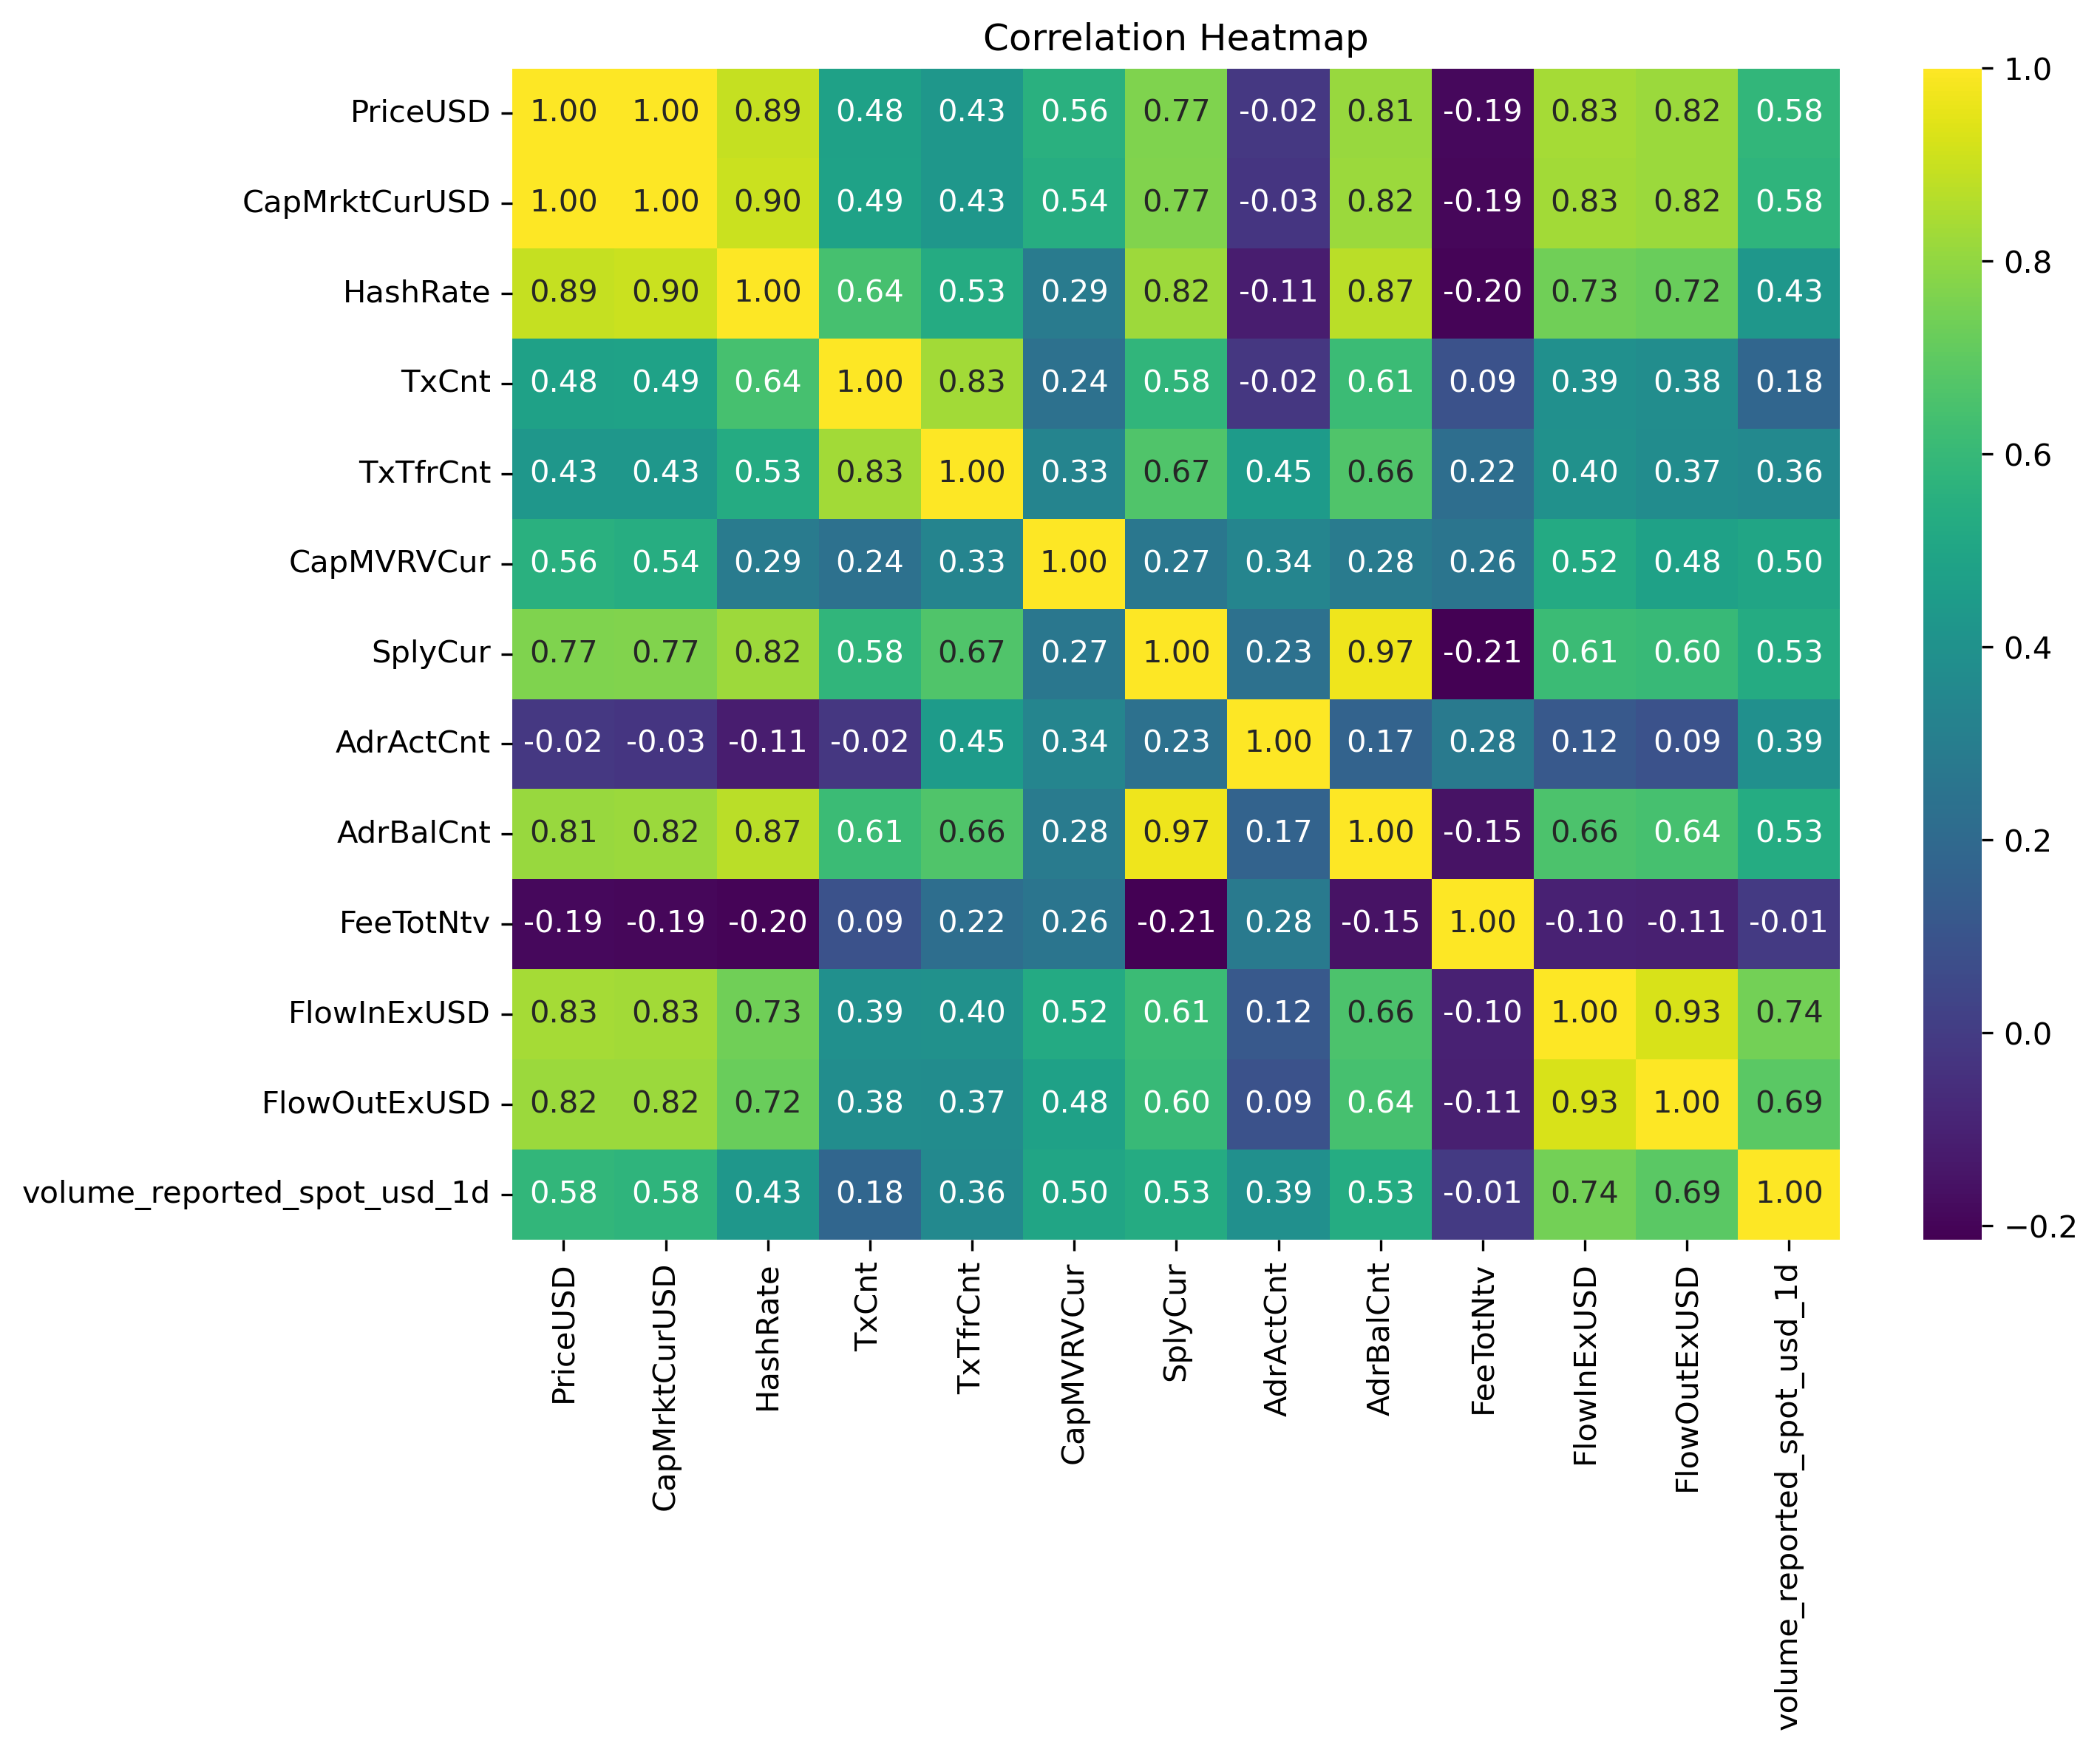

In [18]:
display(Image("plots/correlation_heatmap.png"),width=800)

## 3.2 Polymarket

### Markets

The markets dataset covers crypto, business, and politics categories. Volume is highly concentrated: the top 10 events by cluster account for a disproportionate share of total traded volume. The largest clusters are macro-political events (US elections, inauguration, Fed rate decisions), which is consistent with the expectation that these events carry the most BTC-relevant macro signal.

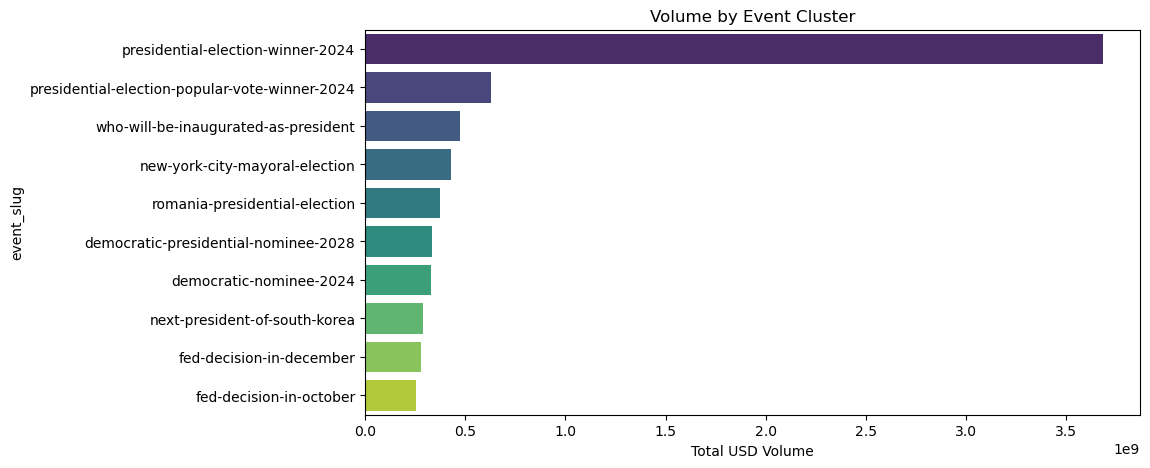

In [5]:
display(Image("plots/VolumeByCluster.png"))

### Trades

The trades dataset contains granular transaction-level records: timestamp, price (0–1 normalized probability), size (token amount), side (BUY/SELL), and wallet addresses for both maker and taker. Trade volume is heavily right-skewed — a small number of large participants account for a large share of total notional. This concentration is the structural basis for the whale signal: a $10k notional threshold captures trades that represent a meaningful fraction of market volume while filtering out retail noise.

**Note on data availability:** The trades parquet export covers April 2025 onward. The whale signal analysis is therefore descriptive for this project cycle; a full historical export would enable complete backtesting.

### Odds History

Approximately 785,000 daily observations from 2023 to 2026, covering price at given timestamp across binary outcome markets. Average probabilities cluster near 0.5 early in market lifecycles and migrate toward 0 or 1 as resolution approaches, reflecting convergence of market belief. The 7-day rolling standard deviation of these probabilities forms the basis of the risk index.

### Events

Event-level volume is highly skewed. Most events are low-volume, while a handful of macro-political events dominate. The top 10 events by volume are predominantly US federal elections, inauguration, and monetary policy decisions — all macro events with direct BTC implications. Event durations vary widely, from single-day binary outcomes to multi-month political contests. 

# 4. Signal Development

In this section, we analyze whether and how Polymarket data can improve a Bitcoin accumulation strategy when combined with on-chain indicators. Each signal is motivated by a specific empirical finding in the EDA before being implemented in the model.

## 4.1 On-Chain Baseline - Signal 1

Before introducing Polymarket data, we first analyze on-chain metrics to establish a baseline accumulation framework. By grouping MVRV, exchange net flow, and active address count into quintiles and examining forward 30-day performance, we observe that MVRV Q1 (most undervalued) levels are generally associated with higher future returns, while higher MVRV levels correspond to increased downside risk. Exchange inflows appear to be more informative for risk than for return, as strong inflows are often followed by higher drawdown probability. Active address count shows a non-linear relationship with volatility, where both very low and very high activity levels are linked to elevated risk. 

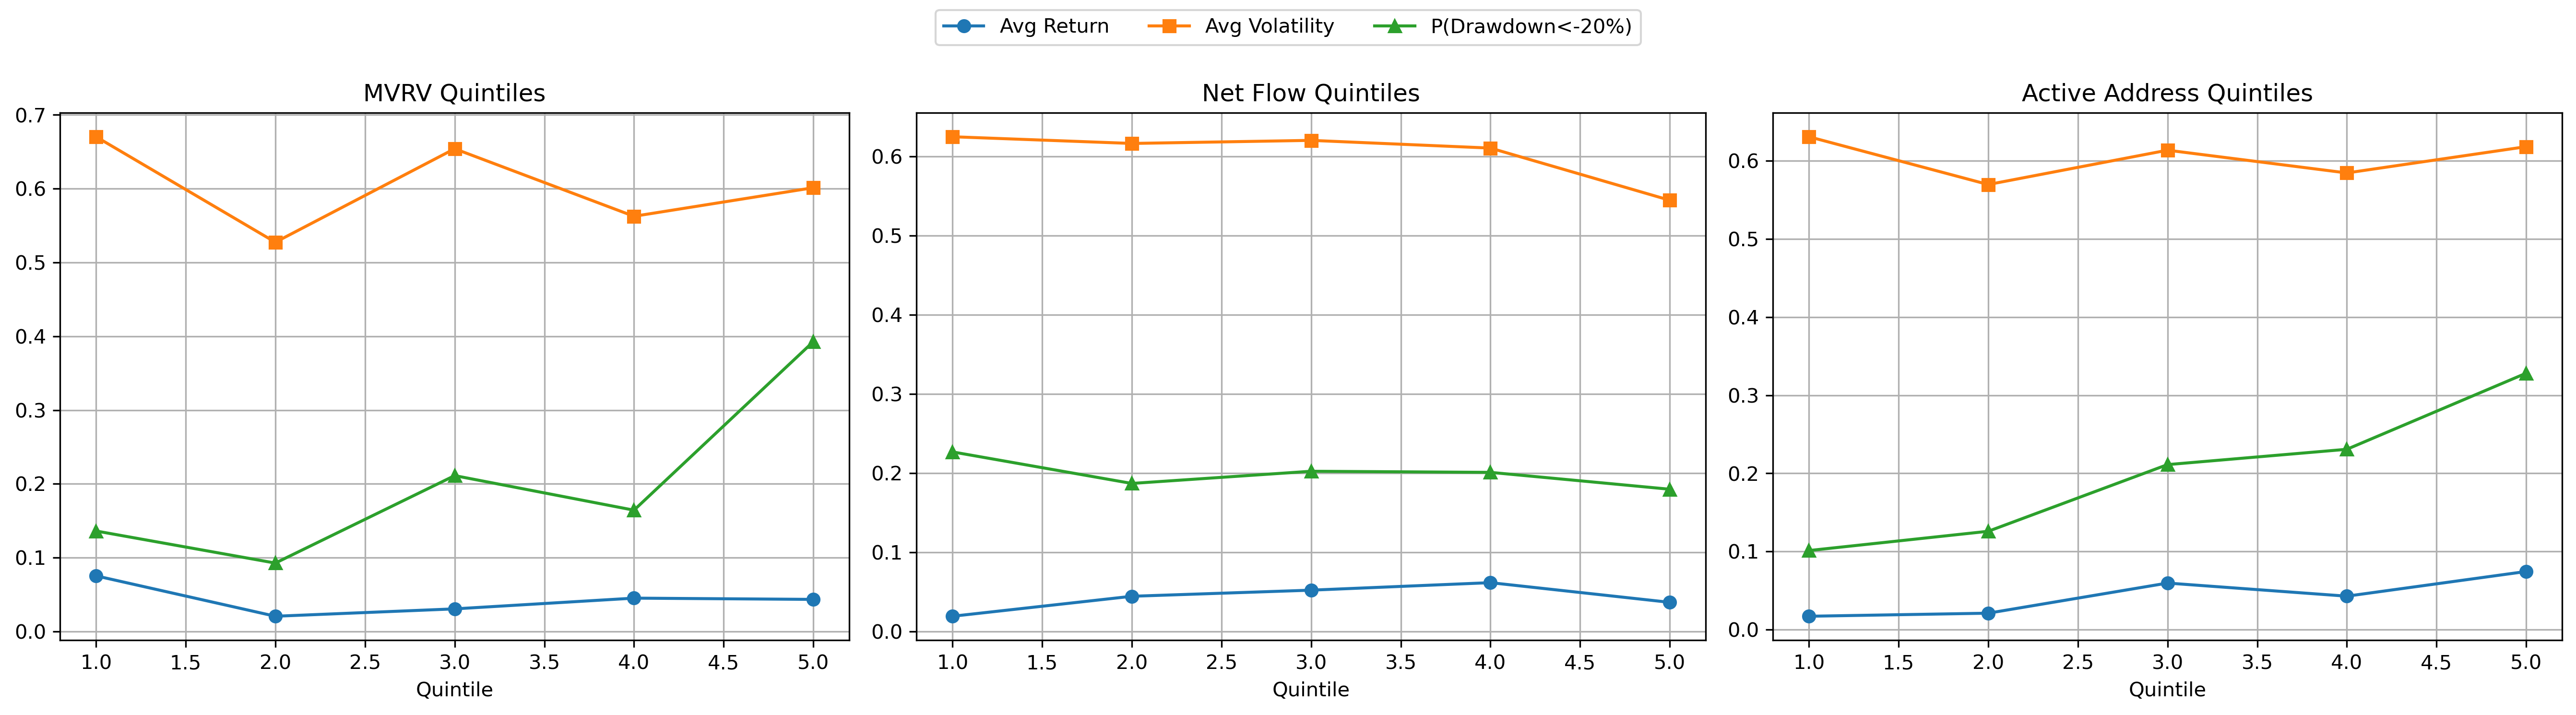

In [6]:
display(Image("plots/Forward_30D_Factor_Comparison.png"))

When combining MVRV and net flow together, the most favorable forward returns occur when BTC is relatively undervalued but net flow remains moderate rather than extreme, suggesting that optimal accumulation may occur during active but stable market conditions rather than during panic-driven 
outflows.
This finding directly motivates the Signal 1 construction: a composite of (1) net flow zscore (2) active address count percentile

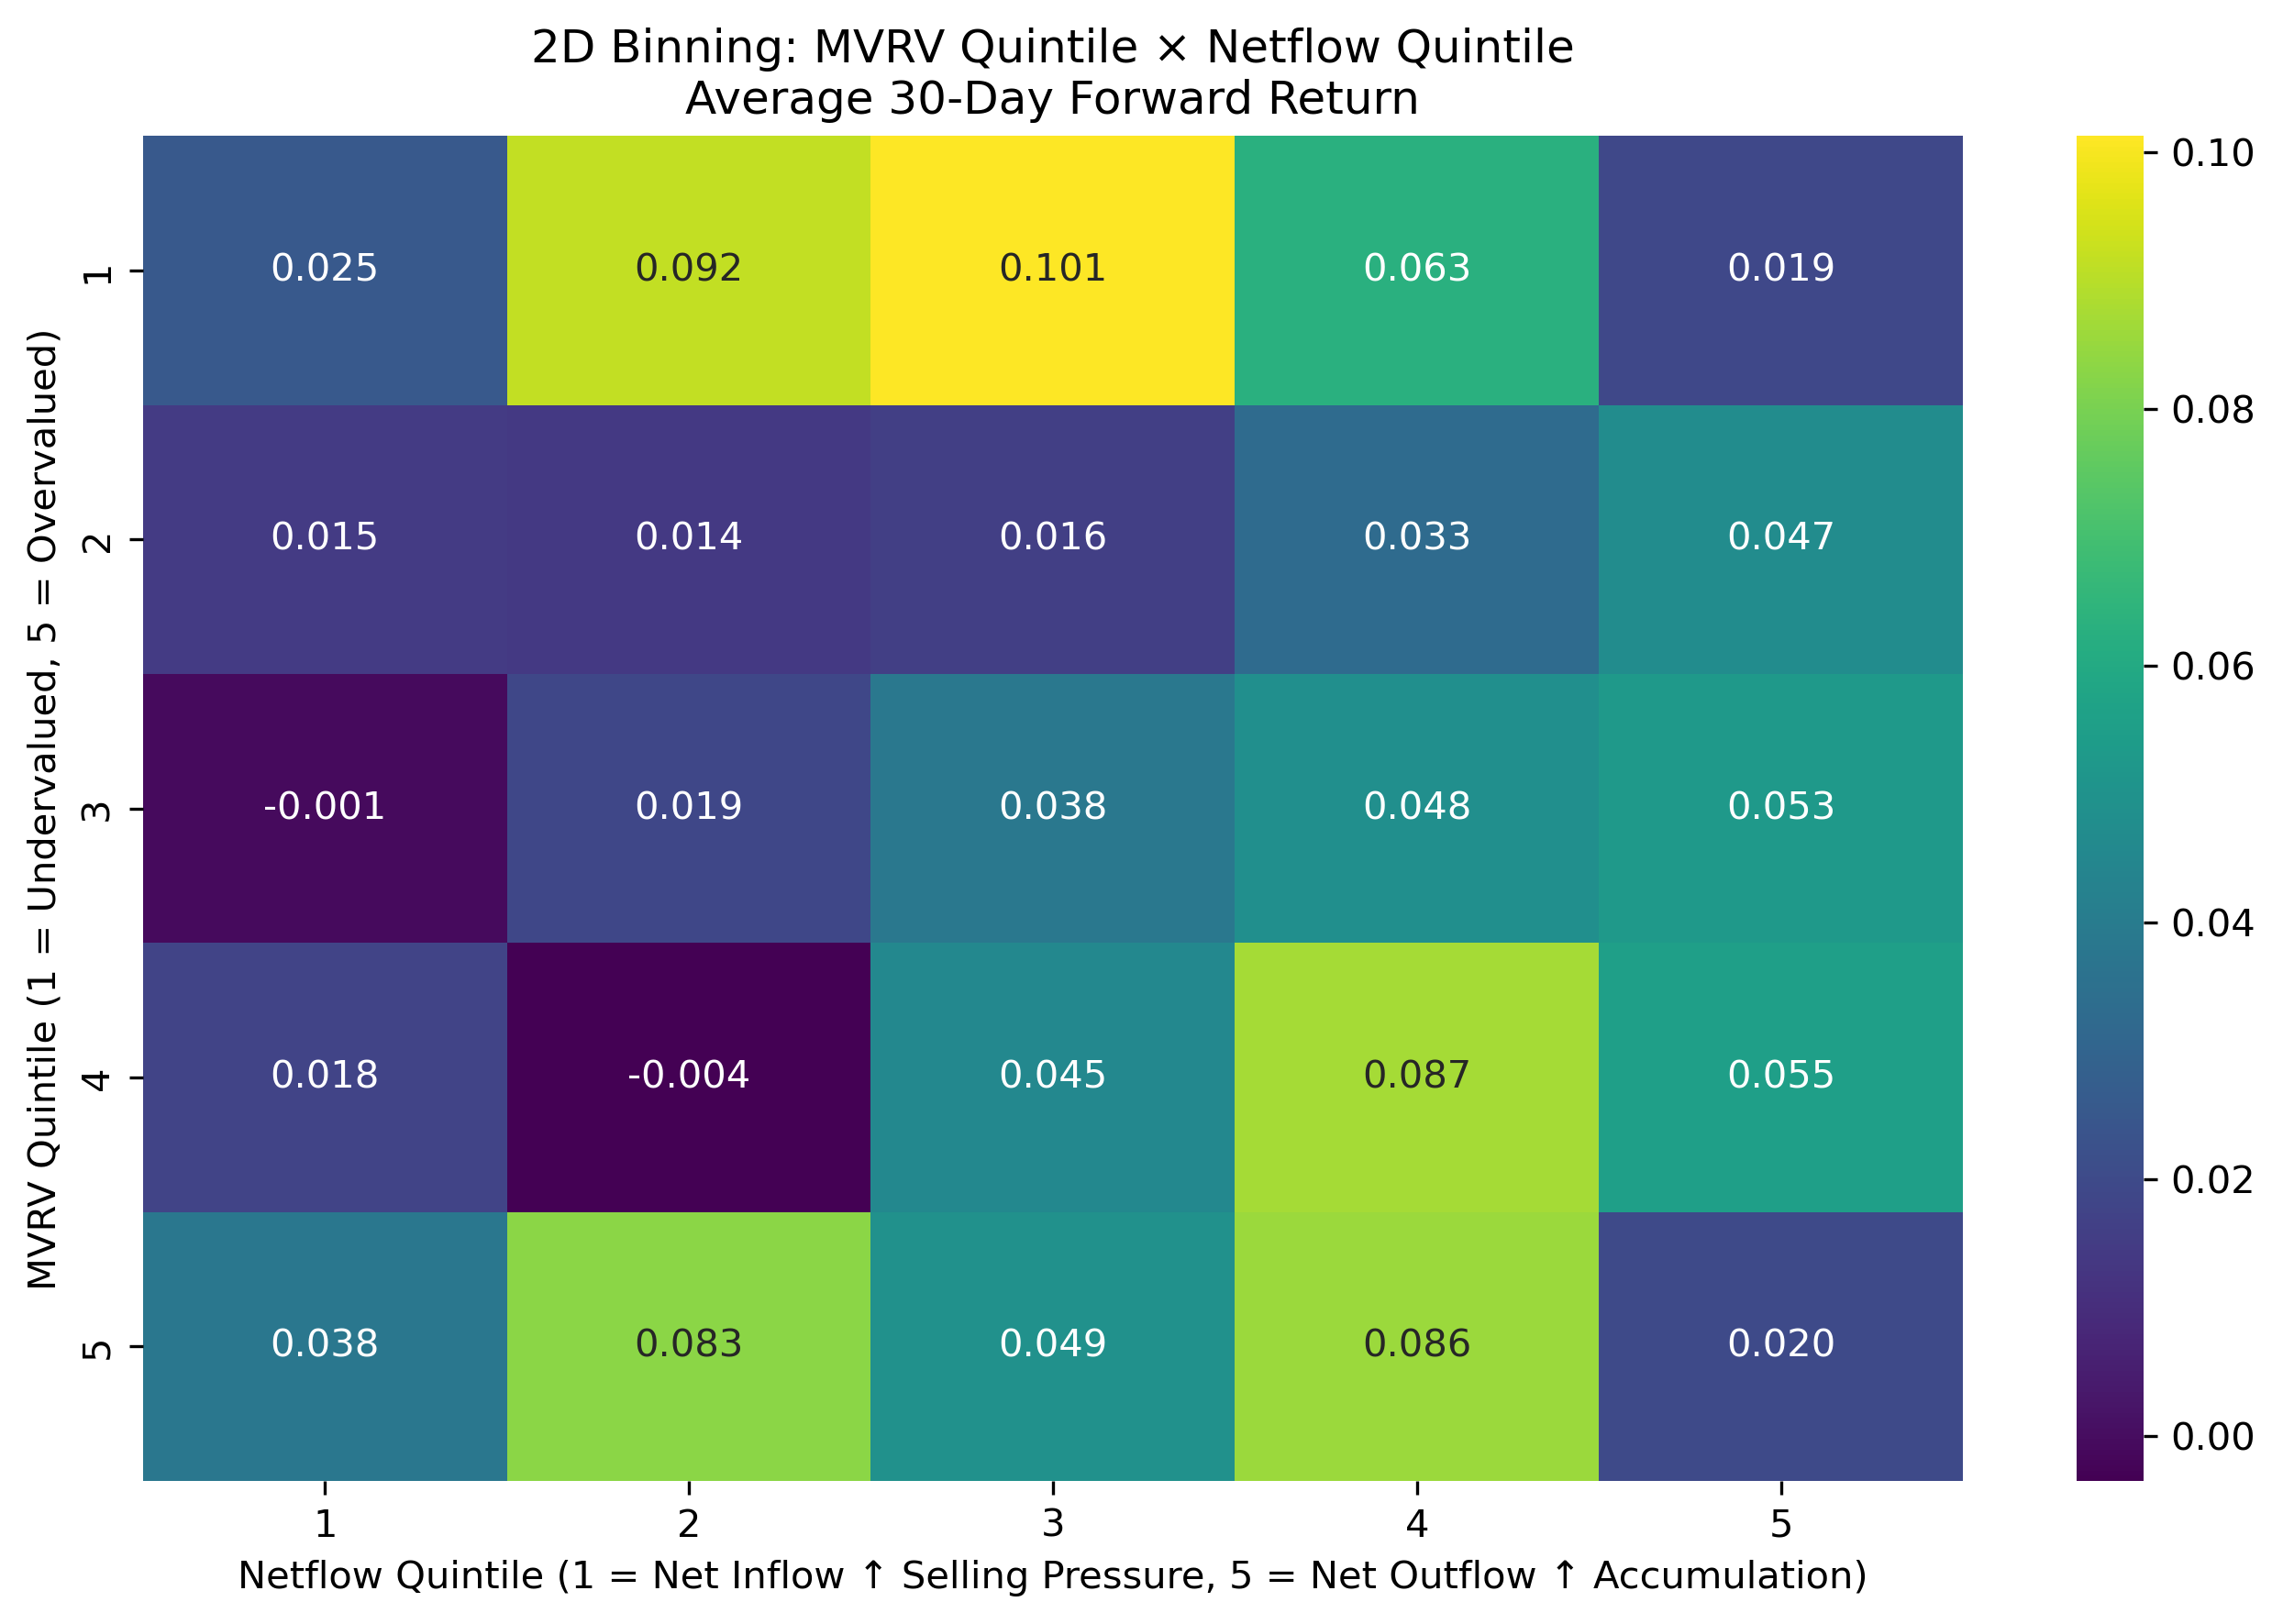

In [17]:
display(Image("plots/2D Binning.png", width=800))

## 4.2 Macro Event Anchor - Signal 2
### 4.2.1 Event Intensity as a Risk Regime Filter

We then incorporate Polymarket event-level data by constructing daily measures such as active event count and total active event volume. When grouping days by event intensity quintiles, we do not observe a consistent directional pattern in forward 30-day returns. However, a clearer structure emerges when focusing on downside risk. Moderate-to-high event intensity days are associated with a lower probability of experiencing a -20% drawdown in the following 30 days, while days with no event activity show higher downside risk.

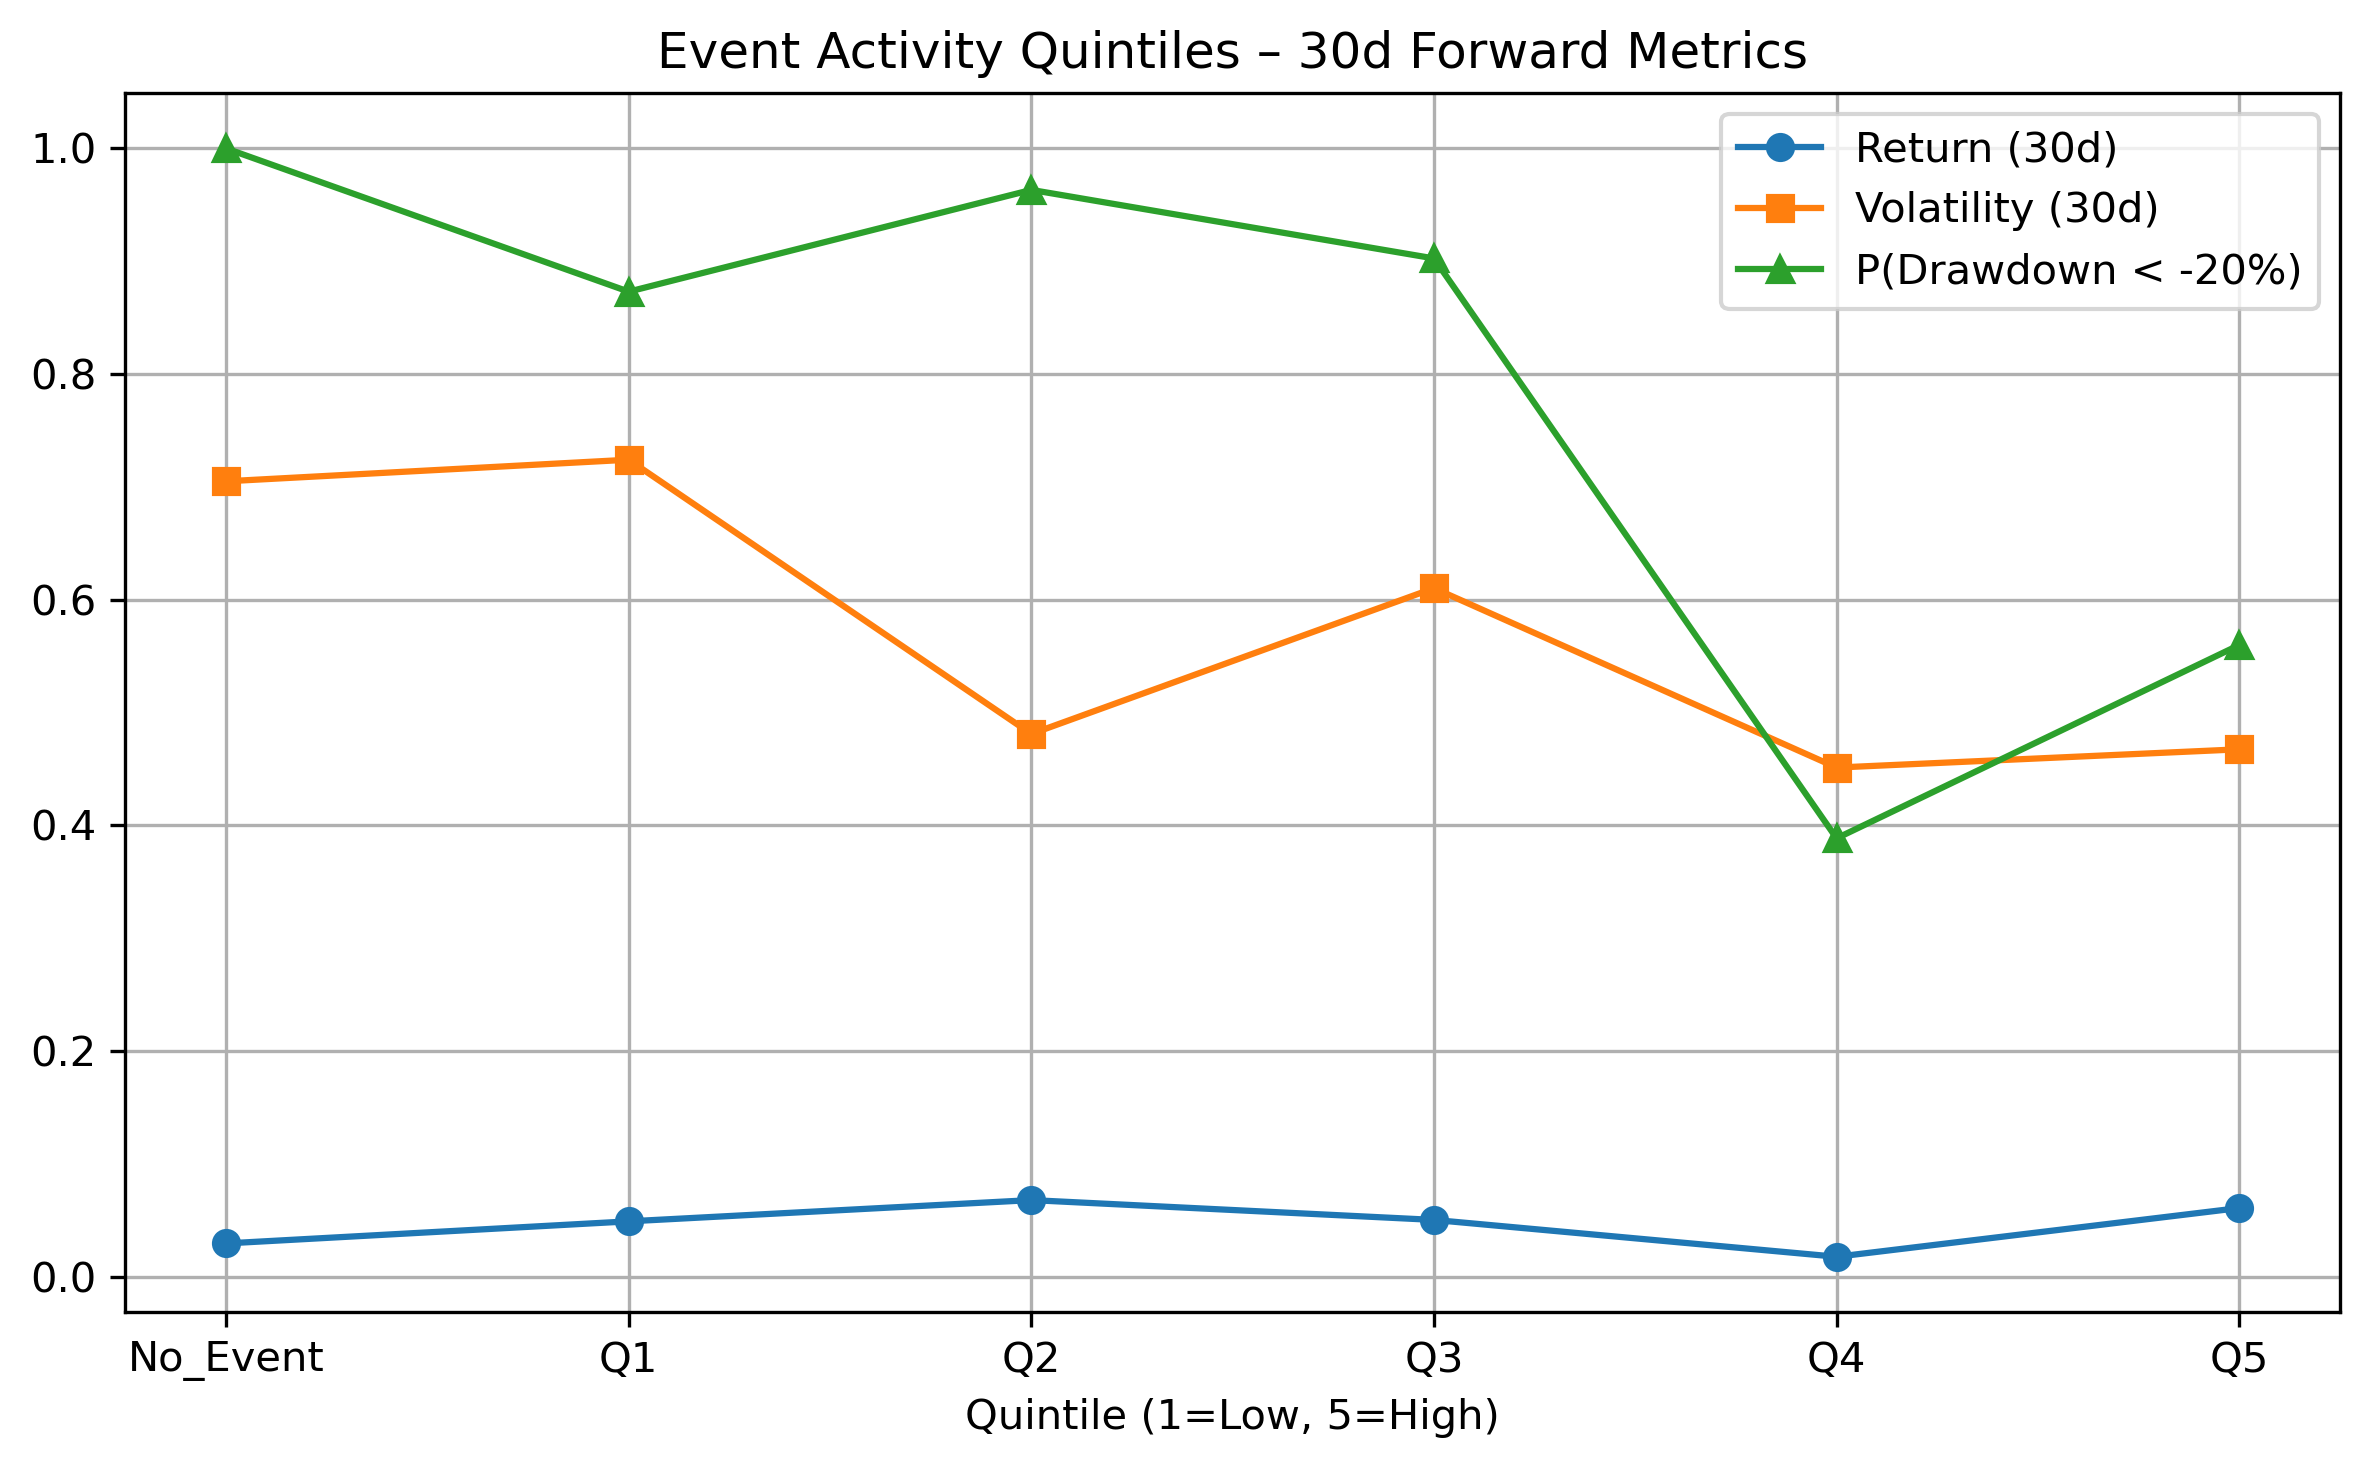

In [15]:
display(Image("plots/event_quintile_forward_metrics.png", width=800))

We further examine whether the probability of the crash exhibits clear structure across different event intensity quintile: low to moderate event days seem to have much higher probability of drawdown.

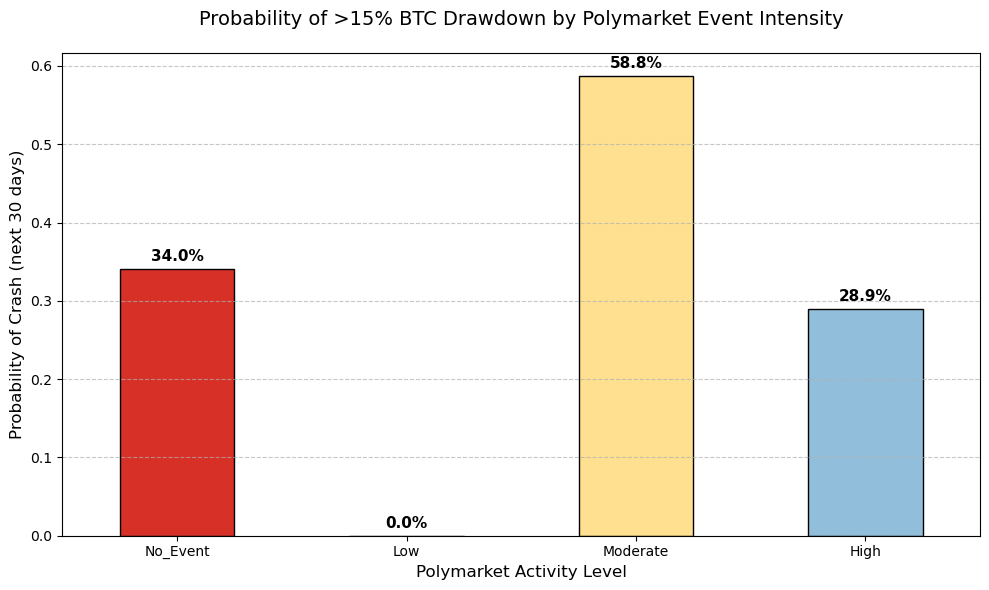

In [28]:
display(Image("plots/EventIntensity.png", width=800))

## 4.2.2 Macro Event Windows and Volatility Behavior

The overlay of Macro Event Windows on the Bitcoin price chart shows: Bitcoin price often trends  toward the predicted outcome of major macro events (e.g., Pro-crypto political shifts). We've also discovered a potential recurring pattern where the variance in BTC price narrows as the "Days to Resolution" for a major Polymarket event decreases. Below example using democractic-nominee-2024 resolution

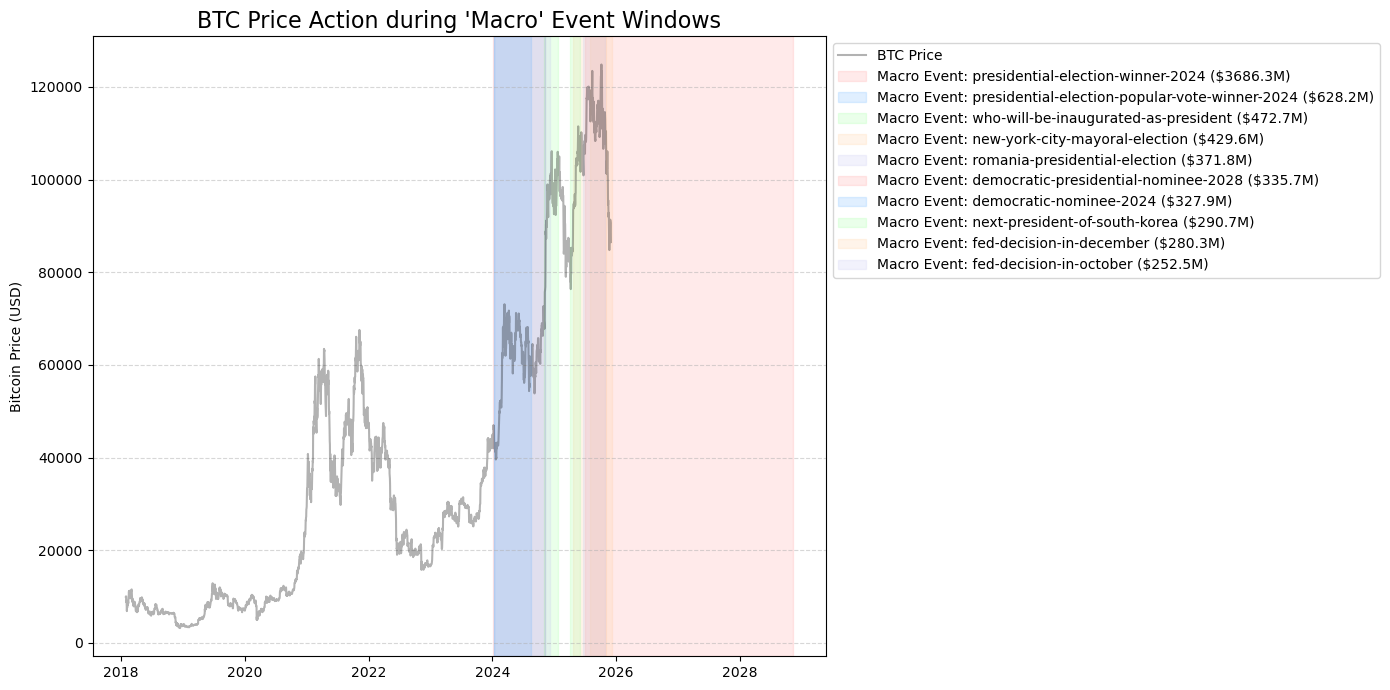

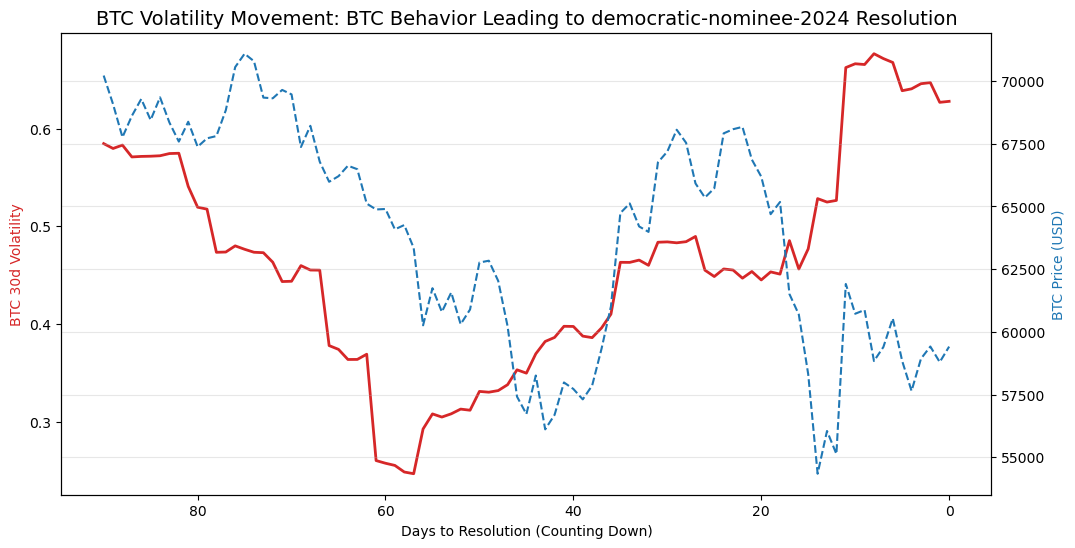

In [29]:
display(Image("plots/BTCPriceMacroWindow.png", width=800))
display(Image("plots/BTCVolMovement.png", width=800))


## 4.3 Smart Money Conviction - Signal 3

The Polymarket trades dataset enables identification of large participants whose bets may carry information beyond the aggregate market. We define such smart money as any transaction with notional larger than $10,000. 

The lead-lag correlation analysis reveals that whale directional flow has a modest positive correlation with BTC returns at short forward lags, suggesting smart money activity slightly anticipates price moves rather than simply reacting to them. The quintile analysis confirms that days where whale flow is most bullish (Q5) are associated with higher average 30-day forward returns and lower drawdown probability than days where whale flow is most bearish (Q1).

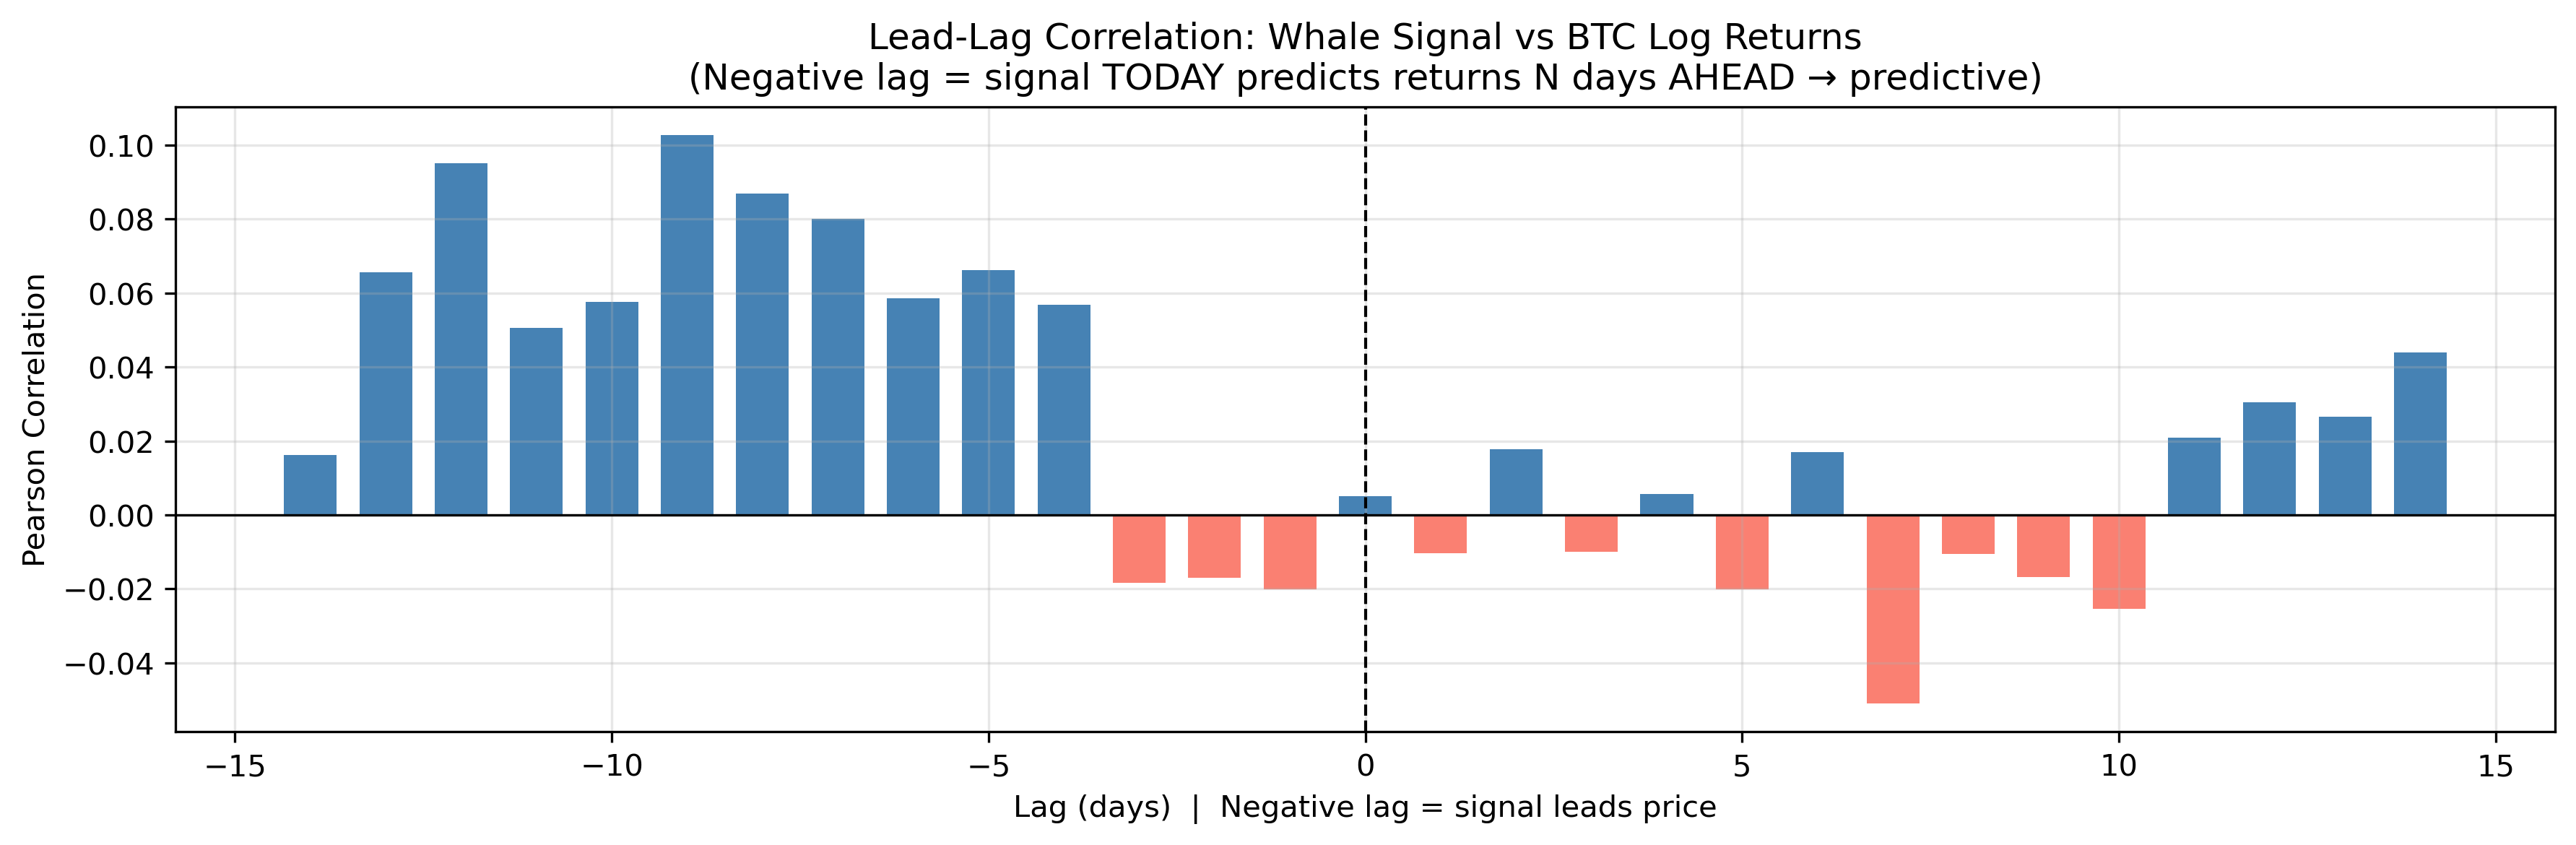

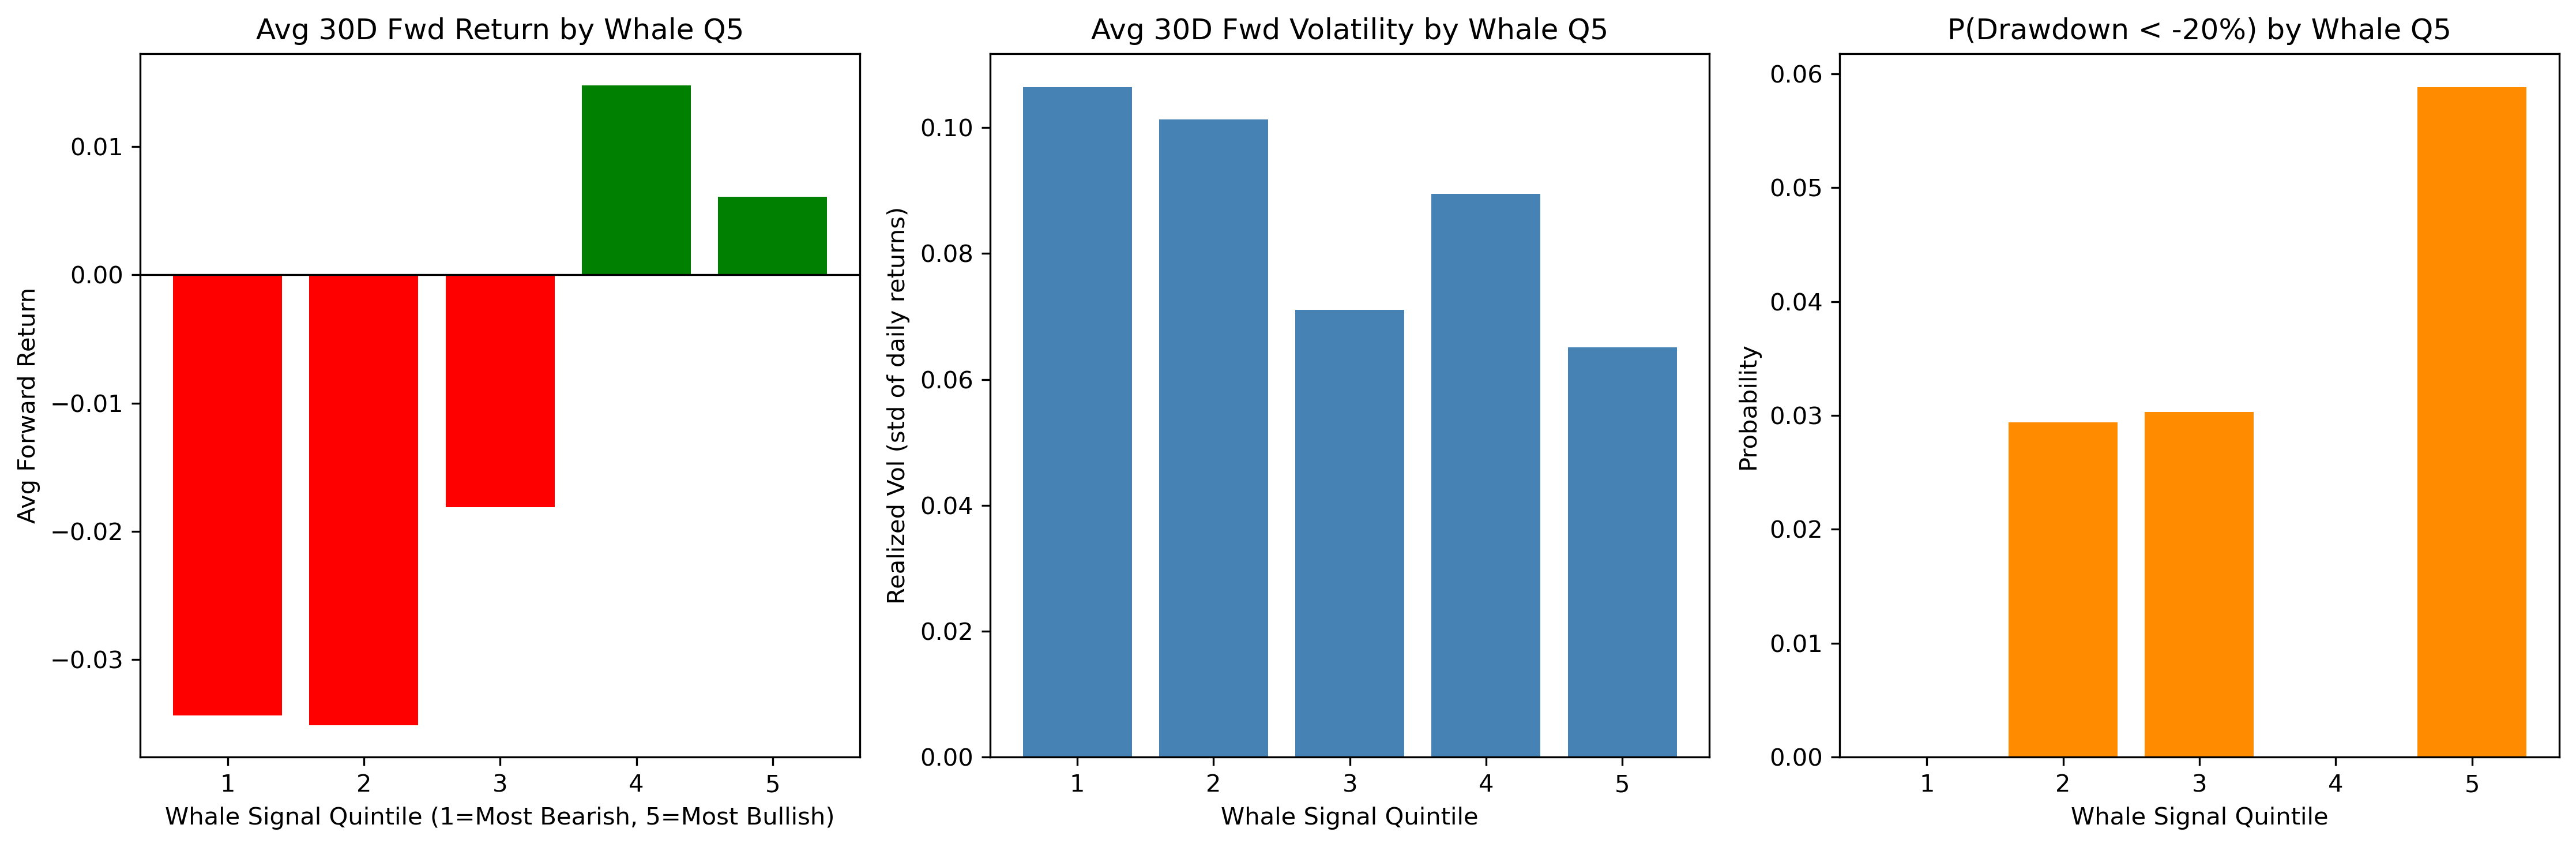

In [31]:
display(Image("plots/whale_lead_lag_correlation.png", width=800))
display(Image("plots/whale_quintile_forward_metrics.png", width=800))

## 4.4 Polymarket Risk Index as a Regime Filter - Signal 4

The Polymarket Risk Index is constructed as the cross-market daily mean of each market's 7-day rolling probability volatility. High values indicate that prediction market participants are rapidly updating their probability estimates — a sign of elevated macro uncertainty and active information processing. Low values indicate stable, slowly-evolving market beliefs.
An analysis of the Oct 2024 – Jan 2025 period showed a massive spike in the Risk Index. While BTC prices were elevated （election period), the forward expectancy during the peak volatility days was significantly lower than during the "quiet" months of Summer 2024. This confirms the index's utility as a risk-regime modifier rather than a simple momentum trigger.
When the risk index is grouped into quintiles and overlaid with BTC average price, a pattern shows that as risk quitile increases from 1 to 3 it coincide with higher average BTC prices while the price is lower as risk increases further. This pattern reflects phase-based co-movement: bull markets may simultaneously produce elevated BTC prices, higher speculative activity, and greater uncertainty across prediction markets.

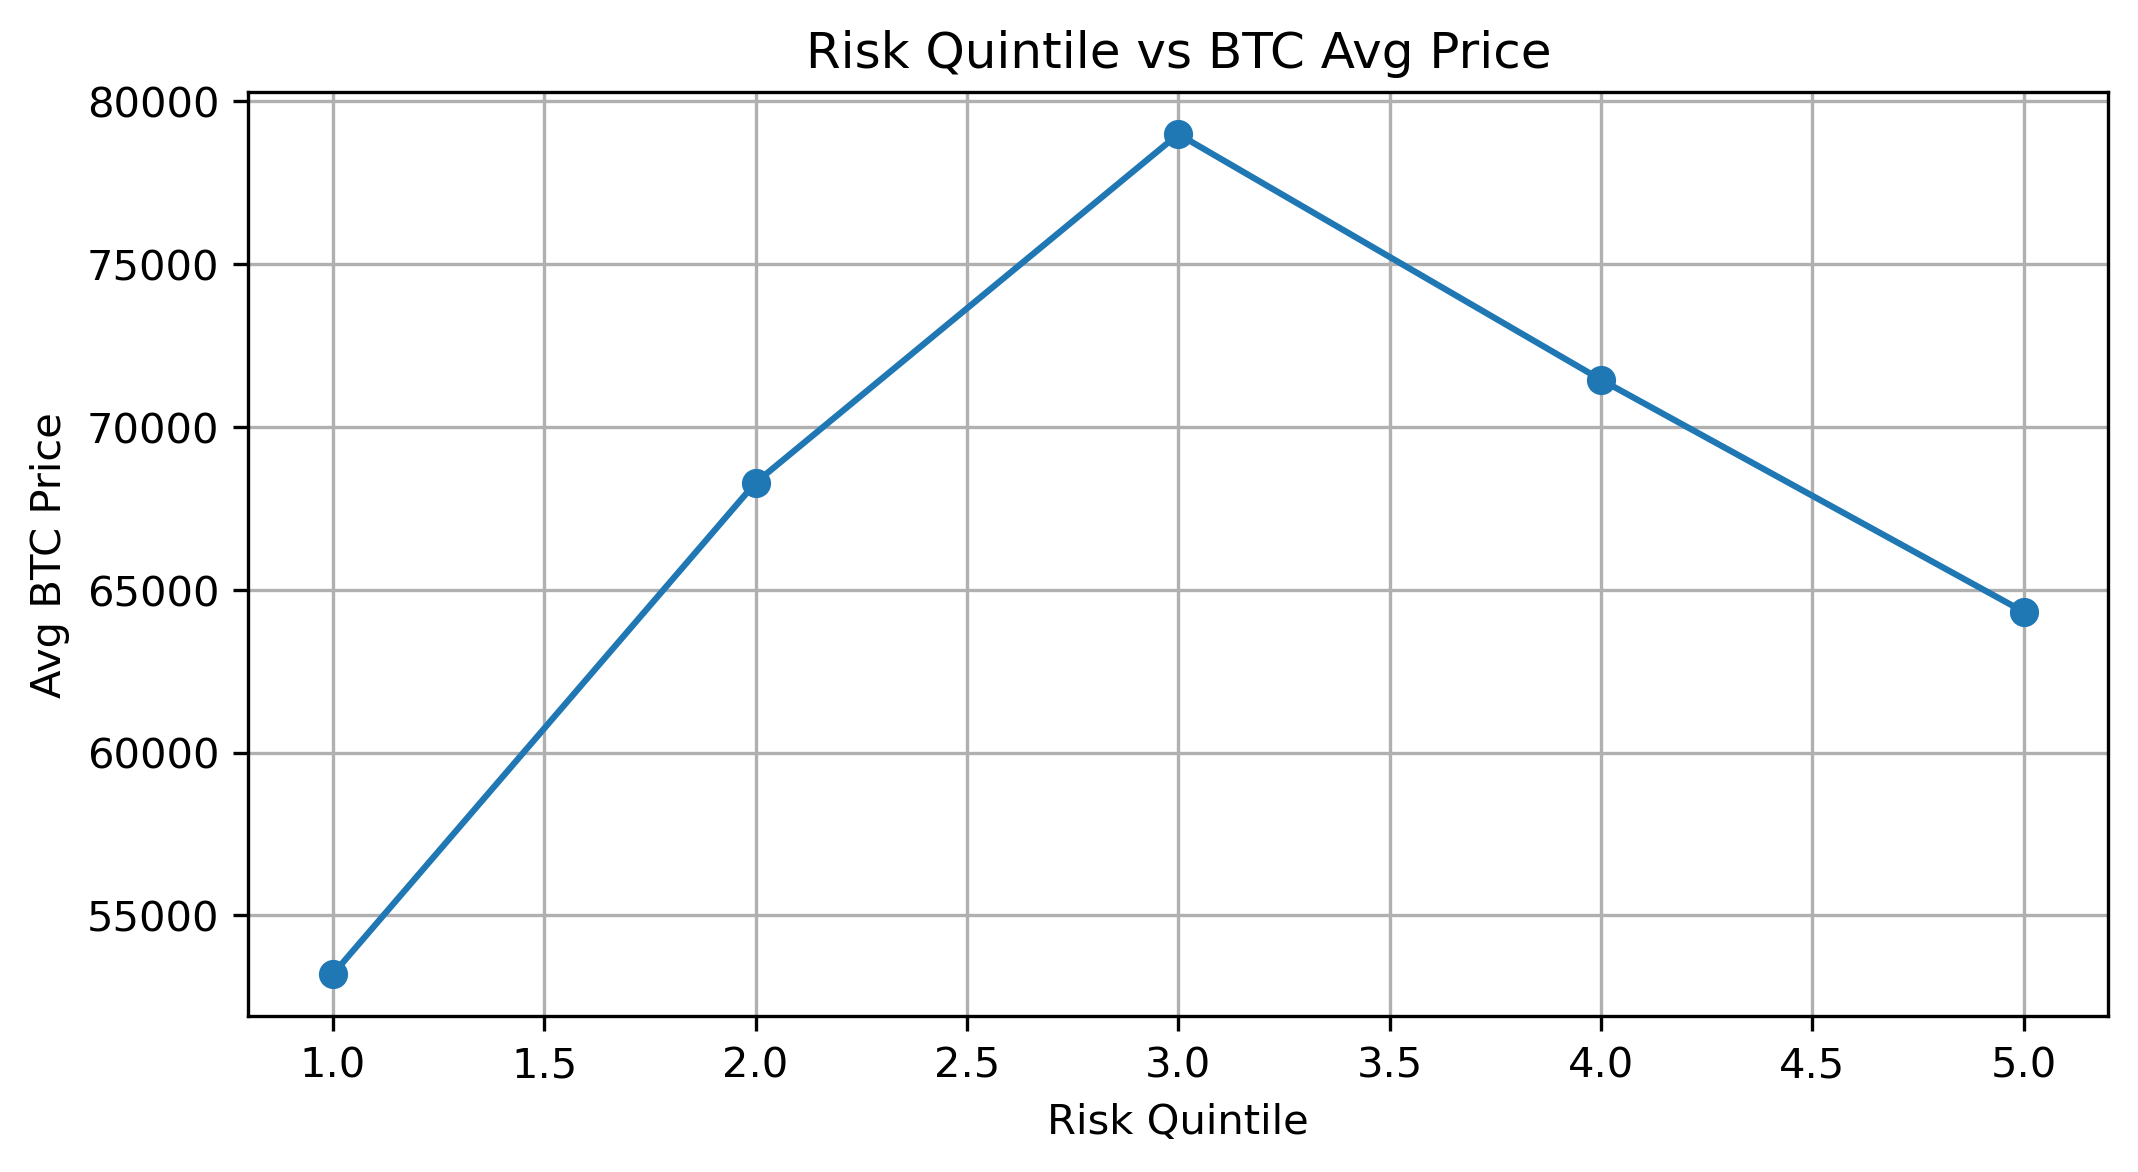

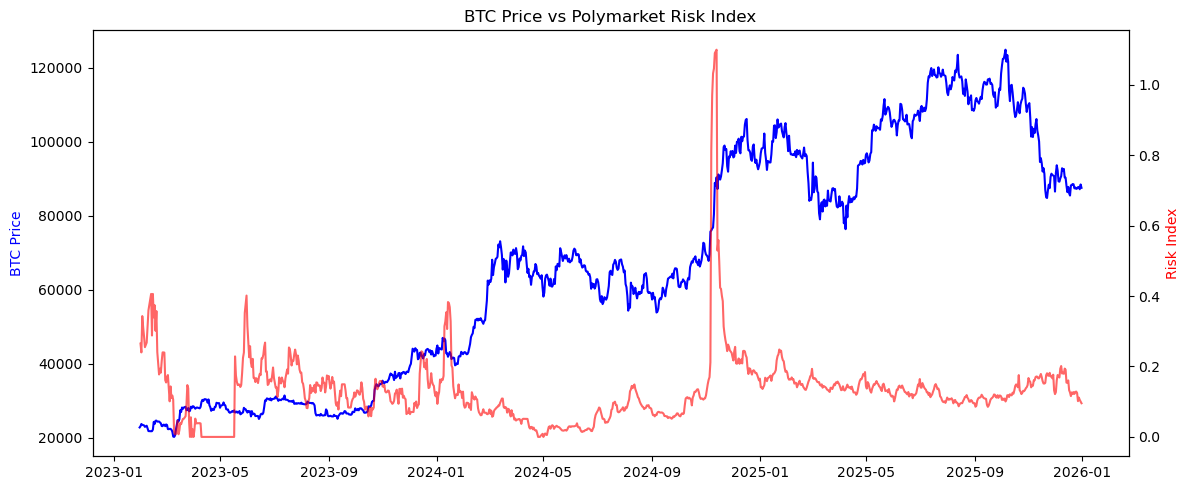

In [34]:
display(Image("plots/Risk_Quintile_vs_BTC_Avg_Price.png", width=800))
display(Image("plots/BTCOdd.png", width=800))

# 5. Model Development and Backtest Results

## 5.1 Data Sources
- CoinMetrics (2018–2025):Price, MVRV, exchange flows, active addresses
- Polymarket (2023–2026):Event activity, trade data, probability odd history

## 5.2 Feature Engineering

We combine the four signals in a layered architecture. All features are lagged by one day before use to prevent any look-ahead bias. Constructed features include:

| Feature | Source | Signal |
|---------|--------|--------|
| MVRV z-score (365-day rolling) | CoinMetrics | Core valuation anchor |
| Price vs. 200-day MA | CoinMetrics | Trend context |
| Net exchange flow z-score | CoinMetrics | Active churn (Signal 1) |
| Active address percentile | CoinMetrics | Active churn (Signal 1) |
| Event proximity dampener | Polymarket markets | Macro event anchor (Signal 2) |
| Event activity gate | Polymarket markets | Macro event anchor (Signal 2) |
| Whale directional flow z-score | Polymarket trades + tokens | Smart money (Signal 3) |
| Risk index regime modifier | Polymarket odds history | Regime filter (Signal 4) |

## 5.3 Model Design

Build upon the example 1 model (DCA + Polymarket sentiment), we implement a dynamic allocation framework that adjusts daily capital deployment relative to standard DCA. The model computes a per-day weight multiplier through two layers:

**Additive core (weighted sum → combined score):**

| Signal | Weight | Direction |
|--------|--------|----------|
| MVRV value signal | 45% | Low z-score = undervalued = buy more |
| 200-day MA deviation | 12% | Price below MA = buy more |
| Active churn composite | 21% | Moderate outflow + active addresses = buy more |
| Whale directional flow | 10% | Bullish big-bet net flow = buy more |

**Multiplicative gates (applied sequentially to refine the combined score):**
- MVRV acceleration modifier — amplifies momentum building, dampens potential reversals
- Signal confidence boost — amplifies when MVRV and MA agree on direction
- MVRV volatility dampening — reduces signal during extreme MVRV uncertainty periods
- Risk regime filter [0.82×, 1.15×] — Signal 4, modifies MVRV component based on Polymarket regime
- Macro event modifier [0.45×, 1.0×] — Signal 2, outermost gate dampening near event resolutions and during informational vacuum periods

The combined score is exponentiated to produce the raw daily multiplier. `allocate_sequential_stable()` then normalises all multipliers within a window so weights sum to exactly 1.0, preserving the total DCA budget while dynamically shifting timing.

## 5.4 Backtest Results

The model is validated using a rolling 1-year window backtest from 2018-01-01 to present (2,557 total windows). For each window, the model's sats-per-dollar (SPD) is compared against uniform DCA. A win is recorded when the model achieves higher SPD. The SPD percentile measures timing quality within each window: 0% is worst possible timing (bought at highest prices), 100% is perfect timing (bought at lowest prices).

| New Model Metric | Value 
|--------|-------
| Final Model Score | 63.4% 
| Win Rate | 68.05% 
| Exponential Decay Percentile | 58.74% 
| Mean Excess Percentile | +7.75% 
| Median Excess Percentile | +7.69% 
| Mean Relative Improvement | +21.1% 
| Median Relative Improvement | +20.72% 
| Mean Ratio (Dynamic/Uniform) | 1.21 
| Total Windows | 2,557  
| Wins | 1,740  
| Losses | 817  

The model beats the simple DCA model based on 200MA in every category. The 68.05% win rate significantly outperform the base model's 51.74% win rate. The Exponential Decay Percentile is improved to 58.74% meaning the smart money and macro modifier signals work pretty well for more recent periods.

| Metric for DCA with 200MA | Value 
|--------|-------
| Final Model Score | 51.74% 
| Win Rate | 61.05% 
| Exponential Decay Percentile | 42.43% 
| Mean Excess Percentile | +1.04% 
| Median Excess Percentile | +1.23% 
| Mean Relative Improvement | +2.61% 
| Median Relative Improvement | +3.37% 
| Mean Ratio (Dynamic/Uniform) | 1.03
| Total Windows | 2,557  
| Wins | 1,561 
| Losses | 996

When comparing with example 1, which is the baseline model + polymarket sentiment derived from new markets creation, the new model still outperforms in every metrics with similar score in exp decay percentile. Interestingly the example 1 model has a lower win rate than the baseline

| Metric for Example 1 model | Value 
|--------|-------
| Final Model Score | 59.54% 
| Win Rate | 60.31% 
| Exponential Decay Percentile | 58.78% 
| Mean Excess Percentile | +5.7% 
| Median Excess Percentile | +6.43% 
| Mean Relative Improvement | +16.82% 
| Median Relative Improvement | +17.99% 
| Mean Ratio (Dynamic/Uniform) | 1.17
| Total Windows | 2,557  
| Wins | 1,542
| Losses | 1015

# 6. Conclusion

This analysis demonstrates that combining on-chain valuation with Polymarket-derived signals produces a measurable improvement over uniform DCA.

The MVRV z-score remains the anchor of the model, providing the strongest single predictor. The active churn composite (Signal 1) adds genuine incremental value by identifying the moderate-outflow, high-engagement regime empirically validated as the most favorable entry window. The macro event modifier (Signal 2) successfully reduces exposure during high-risk informational vacuum periods — the finding that "No Event" days carry materially higher drawdown probability is one of the most robust and actionable in the entire EDA.

The risk index regime filter (Signal 4) contributes sensible regime-awareness but its effect is modest, since the co-movement between the risk index and BTC price is contemporaneous rather than predictive. The whale signal (Signal 3) is structurally promising and the lead-lag analysis shows a mild predictive tilt, but the available data window (April 2025 onward) is too short to validate it empirically through full backtesting.

It is important to note that the current iteration of this model is strictly rule-based. The signal weights and thresholds were derived from heuristic observation rather than a formal optimization process. While this approach provides transparency in the short term, it lacks the mathematical rigor required to find the truly "optimal" allocation across all market conditions.

Three improvements would strengthen the model materially: 

(1) Machine Learning Weight Optimization - employ supervised learning to determine the best weights for each signal

(2) Data Expansion: Obtaining full historical trades to backtest the smart money across the full periods.

(3) Exploring other non liner ensemble Machine Learning models.

